# CNOT primitive time-split scan analysis

This notebook analyzes the target logical error rate for every pre-CNOT/post-CNOT time split independently. For each split it prints the scan summary and displays the target error-rate scan followed by its finite-size-scaling fit. A single combined target-rate fit summary is displayed at the end.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from IPython.display import Markdown, display

from analysis_utils import (
    plot_finite_size_scaling_fit,
    display_fit_summary,
    fit_finite_size_scaling,
    load_ft_scan,
    plot_rate_scan,
)

RESULT_ROOT = Path("../results/cnot_primitive/split_scan")
TIME_SPLITS = [
    ("0_CNOT_T", "0 before, T after"),
    ("Tdiv4_CNOT_3Tdiv4", "T/4 before, 3T/4 after"),
    ("Tdiv2_CNOT_Tdiv2", "T/2 before, T/2 after"),
    ("3Tdiv4_CNOT_Tdiv4", "3T/4 before, T/4 after"),
    ("T_CNOT_0", "T before, 0 after"),
]
P_VALUES = [
    0.010,
    0.011,
    0.012,
    0.013,
    0.014,
    0.015,
    0.016,
    0.017,
    0.018,
    0.019,
    0.020,
]
L_VALUES = [5, 7, 9, 13, 19]

# Change this positive integer to adjust the scaling-polynomial degree.
FIT_DEGREE = 4

## Per-split analysis

### 0 before, T after (`0_CNOT_T`)

Loaded 55 requested CNOT primitive Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


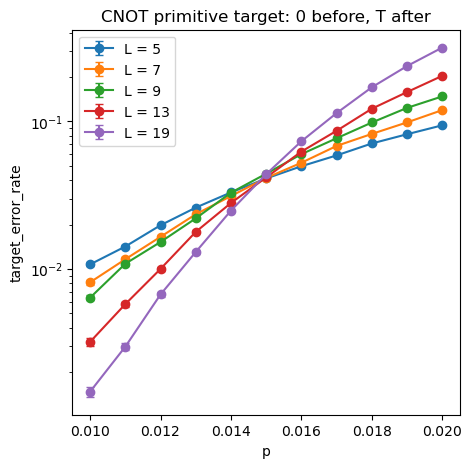

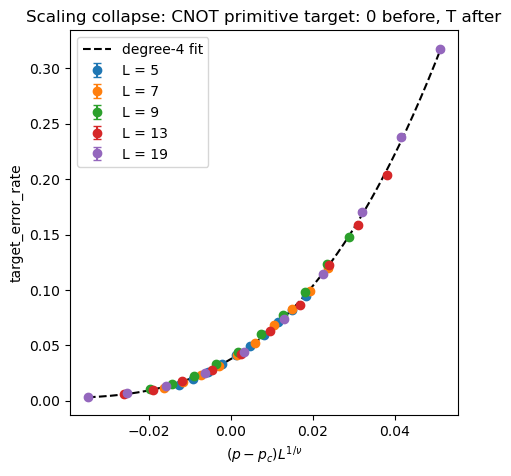

### T/4 before, 3T/4 after (`Tdiv4_CNOT_3Tdiv4`)

Loaded 55 requested CNOT primitive Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


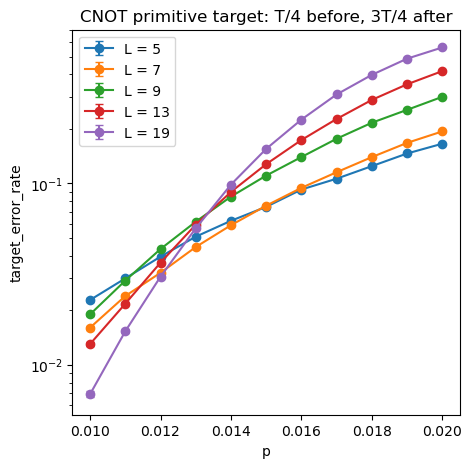

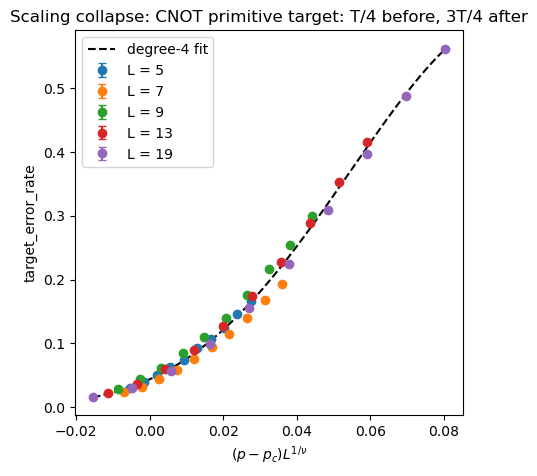

### T/2 before, T/2 after (`Tdiv2_CNOT_Tdiv2`)

Loaded 55 requested CNOT primitive Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


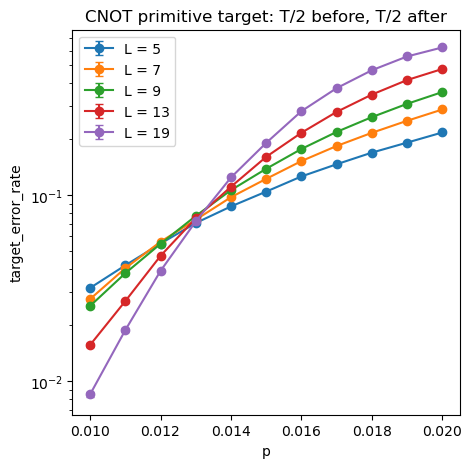

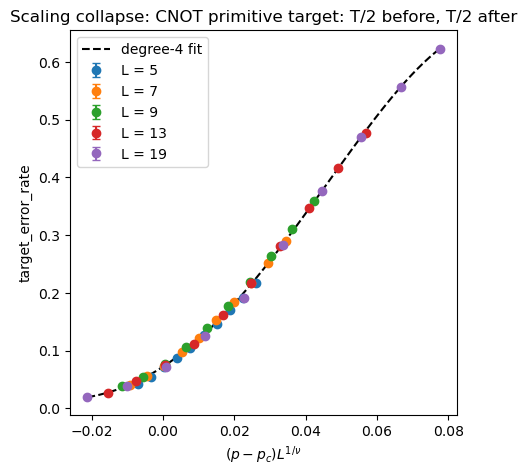

### 3T/4 before, T/4 after (`3Tdiv4_CNOT_Tdiv4`)

Loaded 55 requested CNOT primitive Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


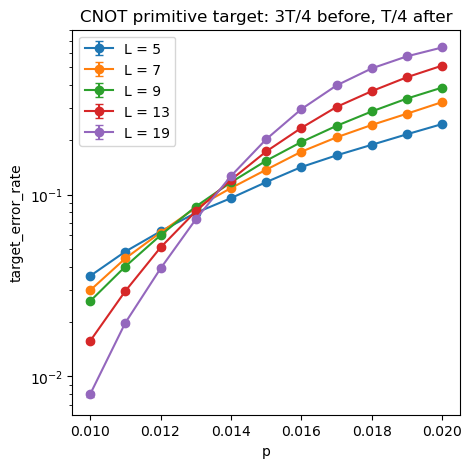

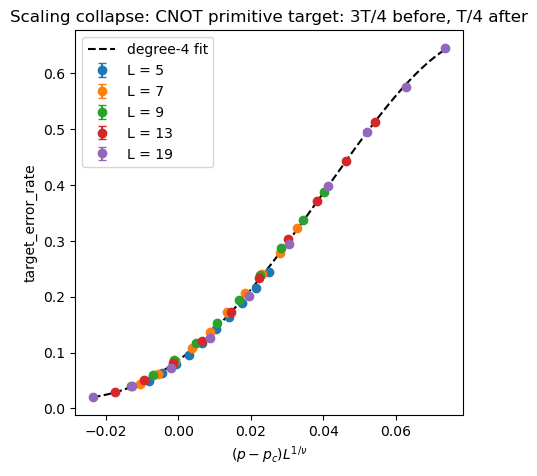

### T before, 0 after (`T_CNOT_0`)

Loaded 55 requested CNOT primitive Ft files; ignored 0 files outside the requested lists
L values: [ 5  7  9 13 19]
p values: [0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02 ]
repeat counts:
 [[1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]]


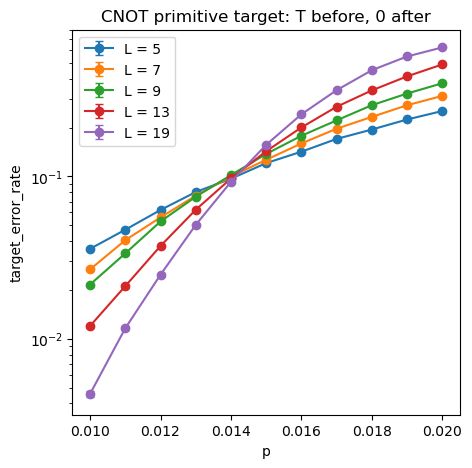

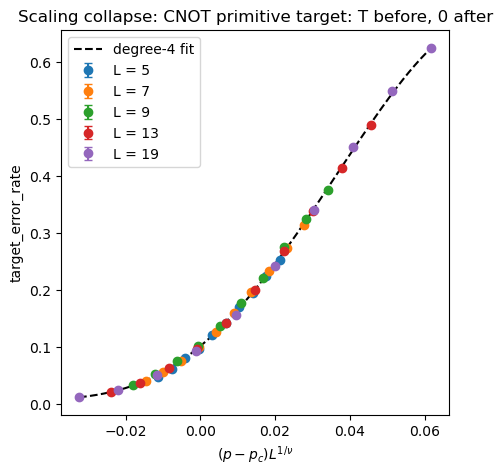

In [2]:
scans = {}
fits = {}

for split_dir, split_label in TIME_SPLITS:
    display(Markdown(f"### {split_label} (`{split_dir}`)"))

    scan = load_ft_scan(
        RESULT_ROOT / split_dir,
        p_values=P_VALUES,
        L_values=L_VALUES,
        expected_repeats=1,
        result_pattern="2d_CNOT_primitive_Ft*.txt",
        success_field="CNOT_Ft",
        failure_fields={"target": "target_logical_failures"},
        scan_label="CNOT primitive Ft",
    )
    scans[split_dir] = scan
    scan.print_summary()

    plot_rate_scan(
        scan,
        rate_name="target",
        title=f"CNOT primitive target: {split_label}",
        ylabel="target_error_rate",
    )

    fit = fit_finite_size_scaling(
        scan,
        rate_name="target",
        label=f"CNOT primitive target: {split_label}",
        polynomial_degree=FIT_DEGREE,
    )
    fits[split_dir] = fit
    plot_finite_size_scaling_fit(fit, "target_error_rate")

## All-split fit summary

In [3]:
display_fit_summary(
    list(fits.values()),
    title="CNOT primitive target fit summary: all time splits",
    include_degree=False,
    include_decimal_pc=False,
)

## CNOT primitive target fit summary: all time splits

| Timing and block | $p_c$ (%) | $\nu$ | $\chi^2 / \mathrm{dof}$ | fit $p$-value |
|---|---:|---:|---:|---:|
| CNOT primitive target: 0 before, T after | 1.465(2) | 1.30(1) | 6.54 | 9.44e-37 |
| CNOT primitive target: T/4 before, 3T/4 after | 1.245(2) | 1.246(9) | 97.51 | 0 |
| CNOT primitive target: T/2 before, T/2 after | 1.293(2) | 1.229(7) | 13.21 | 8.8e-93 |
| CNOT primitive target: 3T/4 before, T/4 after | 1.318(2) | 1.239(7) | 17.07 | 1.53e-126 |
| CNOT primitive target: T before, 0 after | 1.410(1) | 1.254(6) | 8.15 | 7.95e-50 |